In [14]:
import pandas as pd

# input data
df = pd.read_csv("data/Online Retail Data.csv")

print(df.head())

  order_id product_code                     product_name  quantity  \
0   493410      TEST001          This is a test product.         5   
1  C493411        21539          RETRO SPOTS BUTTER DISH        -1   
2   493412      TEST001          This is a test product.         5   
3   493413        21724  PANDA AND BUNNIES STICKER SHEET         1   
4   493413        84578   ELEPHANT TOY WITH BLUE T-SHIRT         1   

            order_date  price  customer_id  
0  2010-01-04 09:24:00   4.50      12346.0  
1  2010-01-04 09:43:00   4.25      14590.0  
2  2010-01-04 09:53:00   4.50      12346.0  
3  2010-01-04 09:54:00   0.85          NaN  
4  2010-01-04 09:54:00   3.75          NaN  


In [15]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  str    
 1   product_code  461773 non-null  str    
 2   product_name  459055 non-null  str    
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  str    
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 24.7 MB
None


Data Cleaning

In [16]:
import datetime as dt
import numpy as np
df_clean=df.copy()


#konversi kolom order_date menjadi datetime
df_clean['date']=pd.to_datetime(df_clean['order_date']).dt.date.astype('datetime64[ns]')


#menghapus semua baris tanpa customer_id
df_clean=df_clean.dropna(subset=['customer_id'])

# menghapus semua baris tanpa product_name
df_clean=df_clean.dropna(subset=['product_name'])

# membuat semua product_name menjadi huruf kecil
df_clean['product_name']=df_clean['product_name'].str.lower()

#menghapus semua baris dengan product_code atau product_name yang mengandung kata test
df_clean = df_clean[(~df_clean['product_code'].str.lower().str.contains('test')) |
                    (~df_clean['product_name'].str.contains('test '))]

# melakukan data cleansing , denngan menghapus baris dengan status 'cancelled'
df_clean=df_clean[df_clean['order_id'].str[:1]!='C']

# mengubaha nilai quantity yang negatif menjadi positif
df_clean['quantity']=df_clean['quantity'].abs()

# menghapus baris dengan price yang negatif
df_clean=df_clean[df_clean['price']>=0]

# membuat nilai amount, yaitu hasil perkalian quantity dan price
df_clean['amount']=df_clean['quantity']*df_clean['price']


# mengganti product_name dari  product_code yang memiliki beberapa product_name dengan salah satu product_name-nya yang paling sering muncul
most_freq_product_name = df_clean.groupby(['product_code','product_name'], as_index=False).agg(order_cnt=('order_id','nunique')).sort_values(['product_code','order_cnt'], ascending=[True,False])
most_freq_product_name['rank'] = most_freq_product_name.groupby('product_code')['order_cnt'].rank(method='first', ascending=False)
most_freq_product_name = most_freq_product_name[most_freq_product_name['rank']==1].drop(columns=['order_cnt','rank'])
df_clean = df_clean.merge(most_freq_product_name.rename(columns={'product_name':'most_freq_product_name'}), how='left', on='product_code')
df_clean['product_name'] = df_clean['most_freq_product_name']
df_clean = df_clean.drop(columns='most_freq_product_name')


# mengkonversi customer_id menjadi string
df_clean['customer_id'] = df_clean['customer_id'].astype(str)


# menghapus outlier
from scipy import stats
df_clean = df_clean[(np.abs(stats.zscore(df_clean[['quantity','amount']]))<3).all(axis=1)]
df_clean = df_clean.reset_index(drop=True)
df_clean

,order_id,product_code,product_name,quantity,order_date,price,customer_id,date,amount
0,493414,21844,red retrospot mug,36,2010-01-04 10:28:00,2.55,14590.0,2010-01-04,91.80
1,493414,21533,retro spot large milk jug,12,2010-01-04 10:28:00,4.25,14590.0,2010-01-04,51.00
2,493414,37508,new england ceramic cake server,2,2010-01-04 10:28:00,2.55,14590.0,2010-01-04,5.10
3,493414,35001G,hand open shape gold,2,2010-01-04 10:28:00,4.25,14590.0,2010-01-04,8.50
4,493414,21527,red retrospot traditional teapot,12,2010-01-04 10:28:00,6.95,14590.0,2010-01-04,83.40
...,...,...,...,...,...,...,...,...,...
350100,539988,84380,set of 3 butterfly cookie cutters,1,2010-12-23 16:06:00,1.25,18116.0,2010-12-23,1.25
350101,539988,84849D,hot baths soap holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12-23,1.69
350102,539988,84849B,fairy soap soap holder,1,2010-12-23 16:06:00,1.69,18116.0,2010-12-23,1.69
350103,539988,22854,cream sweetheart egg holder,2,2010-12-23 16:06:00,4.95,18116.0,2010-12-23,9.90


Duplikat dan Missing values

In [17]:
df_clean.duplicated().sum()

np.int64(6380)

In [18]:
df_drop = df_clean.copy()
df_drop = df_drop.drop_duplicates()
df_drop.duplicated().sum()

np.int64(0)

In [19]:
df_drop.isna().sum()

order_id        0
product_code    0
product_name    0
quantity        0
order_date      0
price           0
customer_id     0
date            0
amount          0
dtype: int64

In [20]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 350105 entries, 0 to 350104
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      350105 non-null  str           
 1   product_code  350105 non-null  str           
 2   product_name  350105 non-null  str           
 3   quantity      350105 non-null  int64         
 4   order_date    350105 non-null  str           
 5   price         350105 non-null  float64       
 6   customer_id   350105 non-null  str           
 7   date          350105 non-null  datetime64[ns]
 8   amount        350105 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), str(5)
memory usage: 24.0 MB


Buat DataFrame Basket

In [21]:
basket=pd.pivot_table(df_clean,index='order_id', columns='product_name', values= 'product_code',
                      aggfunc='nunique', fill_value=0)
basket

product_name,10 colour spaceboy pen,12 ass zinc christmas decorations,12 coloured party balloons,12 daisy pegs in wood box,12 egg house painted wood,12 ivory rose peg place settings,12 message cards with envelopes,12 mini toadstool pegs,12 pencil small tube woodland,12 pencils small tube posy,...,zinc heart lattice charger large,zinc heart lattice charger small,zinc heart lattice double planter,zinc heart lattice planter bowl,zinc heart lattice t-light holder,zinc heart lattice tray oval,zinc metal heart decoration,zinc police box lantern,zinc top 2 door wooden shelf,zinc willie winkie candle stick
order_id,,,,,,,,,,,,,,,,,,,,,
493414,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
493427,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
493428,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
493432,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
493433,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539981,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
539982,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
539985,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Encode DataFrame basket denga nilai True untuk semua nilai daiatas 0 dan False untuk semua nilai 0

In [23]:
def encode(x):
    if x==0:
        return False
    if x>0:
        return True


basket_encode=basket.map(encode)
basket_encode

product_name,10 colour spaceboy pen,12 ass zinc christmas decorations,12 coloured party balloons,12 daisy pegs in wood box,12 egg house painted wood,12 ivory rose peg place settings,12 message cards with envelopes,12 mini toadstool pegs,12 pencil small tube woodland,12 pencils small tube posy,...,zinc heart lattice charger large,zinc heart lattice charger small,zinc heart lattice double planter,zinc heart lattice planter bowl,zinc heart lattice t-light holder,zinc heart lattice tray oval,zinc metal heart decoration,zinc police box lantern,zinc top 2 door wooden shelf,zinc willie winkie candle stick
order_id,,,,,,,,,,,,,,,,,,,,,
493414,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493427,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493428,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493432,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493433,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539981,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
539982,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
539985,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Ambil transaksi dengn banyak produck unik lebih dari 1 saja

In [24]:
basket_filter=basket_encode[(basket_encode>0).sum(axis=1)>1]
basket_filter

product_name,10 colour spaceboy pen,12 ass zinc christmas decorations,12 coloured party balloons,12 daisy pegs in wood box,12 egg house painted wood,12 ivory rose peg place settings,12 message cards with envelopes,12 mini toadstool pegs,12 pencil small tube woodland,12 pencils small tube posy,...,zinc heart lattice charger large,zinc heart lattice charger small,zinc heart lattice double planter,zinc heart lattice planter bowl,zinc heart lattice t-light holder,zinc heart lattice tray oval,zinc metal heart decoration,zinc police box lantern,zinc top 2 door wooden shelf,zinc willie winkie candle stick
order_id,,,,,,,,,,,,,,,,,,,,,
493414,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493427,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493428,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493432,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
493433,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539978,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
539981,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
539982,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


buat list frequent itemset(kumpulan produk yang sering dibeli)

In [32]:
from mlxtend.frequent_patterns import apriori

frequent_itemset = apriori(basket_filter, min_support=.02, use_colnames=True).sort_values('support', ascending=False).reset_index(drop=True)
frequent_itemset['product_cnt'] = frequent_itemset['itemsets'].apply(lambda x: len(x))
frequent_itemset

,support,itemsets,product_cnt
0,0.177953,frozenset({white hanging heart t-light holder}),1
1,0.099440,frozenset({regency cakestand 3 tier}),1
2,0.096841,frozenset({jumbo bag red retrospot}),1
3,0.079912,frozenset({pack of 72 retro spot cake cases}),1
4,0.078512,frozenset({assorted colour bird ornament}),1
...,...,...,...
300,0.020128,frozenset({area patrolled metal sign}),1
301,0.020128,frozenset({feltcraft doll emily}),1
302,0.020128,"frozenset({72 sweetheart fairy cake cases, 60 ...",2
303,0.020061,frozenset({alarm clock bakelike red}),1


Hitung Nilai support, confidence, dan lift dari setiap pasangan produk yang mungkin

In [33]:
from mlxtend.frequent_patterns import association_rules

product_association= association_rules(frequent_itemset, metric='confidence', min_threshold=.7).sort_values(['support','confidence'], ascending=[False, False]).reset_index(drop=True)
product_association

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({red hanging heart t-light holder}),frozenset({white hanging heart t-light holder}),0.058784,0.177953,0.042455,0.722222,4.058510,1.0,0.031995,2.959371,0.800671,0.218525,0.662090,0.480400
1,frozenset({sweetheart ceramic trinket box}),frozenset({strawberry ceramic trinket box}),0.049254,0.074980,0.037457,0.760487,10.142533,1.0,0.033764,3.862089,0.948103,0.431644,0.741073,0.630021
2,frozenset({toilet metal sign}),frozenset({bathroom metal sign}),0.026993,0.040589,0.021728,0.804938,19.831353,1.0,0.020632,4.918499,0.975918,0.473837,0.796686,0.670121


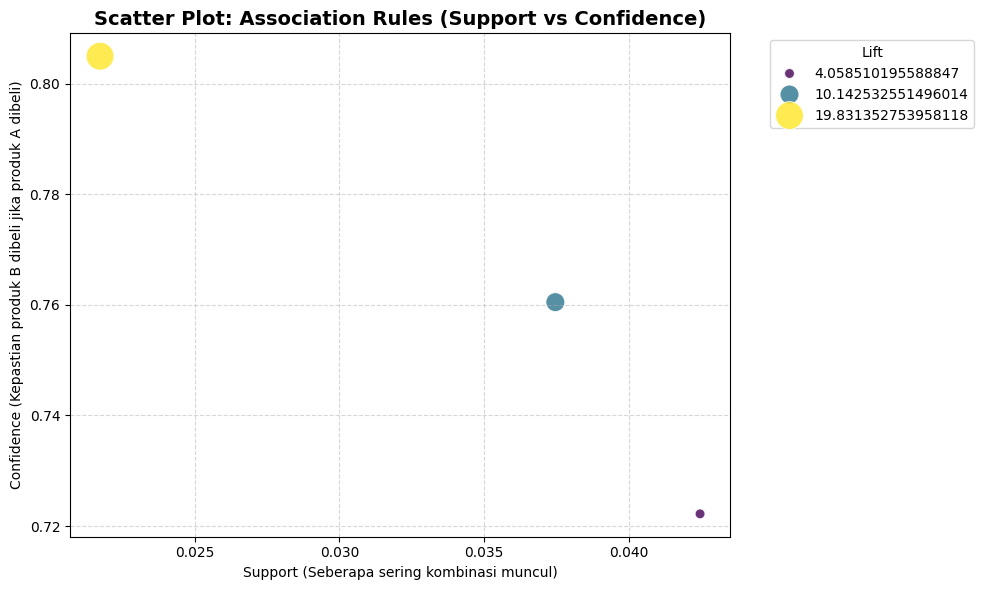

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Membuat scatter plot dari tabel product_association
sns.scatterplot(
    data=product_association, 
    x="support", 
    y="confidence", 
    size="lift",     # Ukuran titik ditentukan oleh nilai lift
    hue="lift",      # Warna titik ditentukan oleh nilai lift
    palette="viridis", 
    sizes=(50, 400),
    alpha=0.8
)

plt.title('Scatter Plot: Association Rules (Support vs Confidence)', fontsize=14, fontweight='bold')
plt.xlabel('Support (Seberapa sering kombinasi muncul)')
plt.ylabel('Confidence (Kepastian produk B dibeli jika produk A dibeli)')
plt.legend(title='Lift', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Temuan: